# Neural Network Classifier Pipeline
This notebook demonstrates the pipeline for training, predicting, and evaluating the provided Neural Network, including calculating AUC and significance metrics.

In [ ]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

import joblib
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import os

class NeuralNetwork:
    """
    This class implements a neural network classifier.
    """

    def __init__(self, train_data=None):
        self.model = None
        self.scaler = StandardScaler()

        if train_data is not None:
            self._initialize_model(train_data)

    def _initialize_model(self, train_data):
        """Initialize the model architecture."""
        self.model = Sequential()
        n_dim = train_data.shape[1]

        self.model.add(Dense(325, input_dim=n_dim, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(325, activation="relu"))
        self.model.add(Dense(1, activation="sigmoid"))

        self.model.compile(
            loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
        )

    def fit(self, train_data, y_train, weights_train=None):
        """Train the model."""
        if self.model is None:
            raise ValueError(
                "Model is not initialized. Ensure `_initialize_model` is called or load a saved model."
            )

        self.scaler.fit_transform(train_data)
        X_train = self.scaler.transform(train_data)
        self.model.fit(
            X_train, y_train, sample_weight=weights_train, epochs=25, verbose=2
        )

    def predict(self, test_data, labels=None, weights=None):
        test_data = self.scaler.transform(test_data)
        predictions = self.model.predict(test_data).flatten().ravel()

        # Store predictions for significance calculation
        self.__predicted_data = predictions
        # Optionally store test labels and weights if provided
        if labels is not None:
            self.__test_labels = labels
        if weights is not None:
            self.__test_weights = np.asarray(weights)
        return predictions

    def significance(self, test_labels=None, test_weights=None):
        if test_labels is not None:
            self.__test_labels = test_labels
        if test_weights is not None:
            self.__test_weights = np.asarray(test_weights)
        if self.__test_labels is None:
            raise ValueError(
                "True labels for test data are not available. Please provide them when calling predict()."
            )

        def __amsasimov(s_in, b_in):
            s = np.copy(s_in)
            b = np.copy(b_in)
            s = np.where((b_in == 0), 0.0, s_in)
            b = np.where((b_in == 0), 1.0, b)
            ams = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
            ams = np.where((s < 0) | (b < 0), np.nan, ams)
            if np.isscalar(s_in):
                return float(ams)
            else:
                return ams

        def __significance_vscore(y_true, y_score, sample_weight=None):
            if sample_weight is None:
                sample_weight = np.full(len(y_true), 1.0)
            else:
                sample_weight = np.asarray(sample_weight)
            bins = np.linspace(0, 1.0, 101)
            s_hist, _ = np.histogram(
                y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
            )
            b_hist, _ = np.histogram(
                y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
            )
            s_cumul = np.cumsum(s_hist[::-1])[::-1]
            b_cumul = np.cumsum(b_hist[::-1])[::-1]
            significance = __amsasimov(s_cumul, b_cumul)
            return significance

        vamsasimov_xgb = __significance_vscore(
            y_true=self.__test_labels,
            y_score=self.__predicted_data,
            sample_weight=self.__test_weights,
        )

        plt.plot(np.linspace(0, 1.0, 100), vamsasimov_xgb, label="AMS Significance")
        plt.xlabel("Score")
        plt.ylabel("Significance")
        return np.max(vamsasimov_xgb)

    def save_model(self, path):
        """Save the trained model and scaler to the specified path."""
        if not os.path.exists(path):
            os.makedirs(path)
        model_path = os.path.join(path, "model.h5")
        self.model.save(model_path)
        print(f"Model saved to {model_path}")

        scaler_path = os.path.join(path, "scaler.pkl")
        joblib.dump(self.scaler, scaler_path)
        print(f"Scaler saved to {scaler_path}")

    def load_model(self, path):
        """Load the trained model and scaler from the specified path."""
        model_path = os.path.join(path, "model.h5")
        self.model = load_model(model_path)
        print(f"Model loaded from {model_path}")

        scaler_path = os.path.join(path, "scaler.pkl")
        self.scaler = joblib.load(scaler_path)
        print(f"Scaler loaded from {scaler_path}")


def save(model, scaler, model_str="model.keras", scaler_str="scaler.pkl"):
    joblib.dump(scaler, scaler_str)
    model.save(model_str)

def load(model_str="model.keras", scaler_str="scaler.pkl"):
    model = load_model(model_str)
    scaler = joblib.load(scaler_str)
    return model, scaler

### Generate Synthetic Test Data
We will generate a synthetic classification dataset to test the pipeline. In a real scenario, this would be replaced by your actual dataset.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a binary classification dataset
X, y = make_classification(n_samples=5000, n_features=20, n_classes=2, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Generate some dummy weights (all ones for simplicity, but you can use real weights)
weights_train = np.ones(len(y_train))
weights_test = np.ones(len(y_test))

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

### Train the Model

In [ ]:
# Initialize and train the neural network
nn = NeuralNetwork(train_data=X_train)
print("Starting training...")
nn.fit(X_train, y_train, weights_train=weights_train)
print("Training complete") 


### Test the Model and Evaluate Metrics (AUC & Significance)

 8/32 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

ROC AUC Score: 0.9241


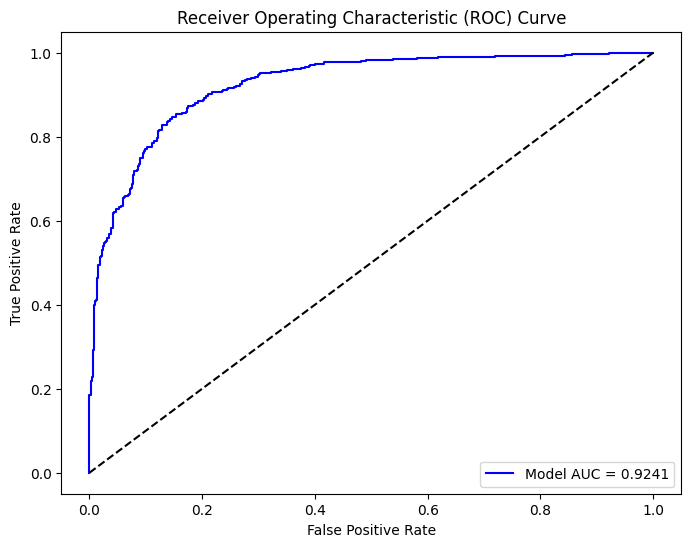

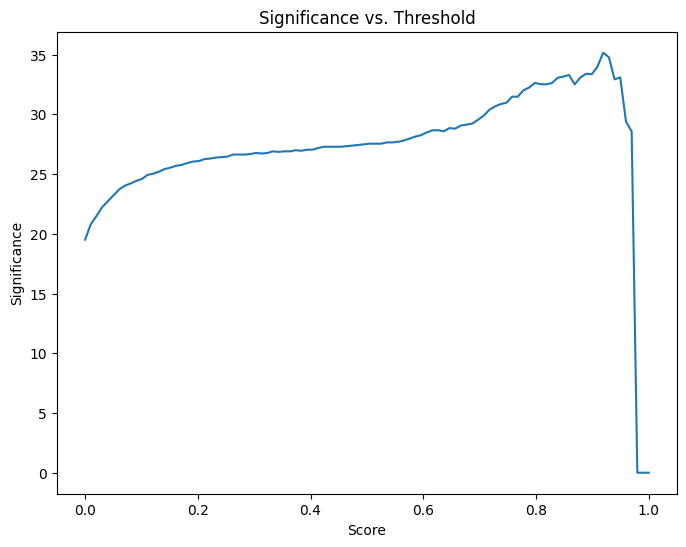

Max Significance: 35.1560


SyntaxError: 'break' outside loop (3790814948.py, line 28)

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict on the test set
predictions = nn.predict(X_test, labels=y_test, weights=weights_test)

# Calculate AUC
auc = roc_auc_score(y_test, predictions, sample_weight=weights_test)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Calculate and Plot Significance
plt.figure(figsize=(8, 6))
max_significance = nn.significance()
plt.title('Significance vs. Threshold')
plt.show()

print(f"Max Significance: {max_significance:.4f}")
break 

### Save and Load the Model

In [ ]:
import tempfile

# Use a temporary directory or specify your own path
model_dir = tempfile.mkdtemp()

# Test class-based save/load
print("Testing class methods:")
nn.save_model(model_dir)

nn_loaded = NeuralNetwork()
nn_loaded.load_model(model_dir)
print("Model loaded successfully via class method.\n")

# Test standalone save/load functions
print("Testing standalone functions:")
model_path_str = os.path.join(model_dir, "model.keras")
scaler_path_str = os.path.join(model_dir, "scaler.pkl")
save(nn.model, nn.scaler, model_str=model_path_str, scaler_str=scaler_path_str)
loaded_model, loaded_scaler = load(model_str=model_path_str, scaler_str=scaler_path_str)
print("Model loaded successfully via standalone functions.")